### Example Fixed Project

The rest of this tutorial uses pre compiled ORBIT configs that are stored as .yaml files in the '~/configs/ folder. There are load and save methods available in ORBIT for working with .yaml files. These example projects each exhibit different functionalities within ORBIT. Using these examples and combinations of them, most project configurations can be modeled. 

In [1]:
import os
import pandas as pd
from ORBIT import ProjectManager, load_config

weather = pd.read_csv("data/boem_era5_39.0_-74.5.csv", parse_dates=["datetime"])\
            .set_index("datetime")

### Load the project configuration

In [2]:
fixed_config = load_config("configs/CVOW_C_base_install.yaml")  # Configs can be loaded with absolute or relative paths

print(type(fixed_config))                                         # They are loaded in as dictionaries.

print(f"Num turbines: {fixed_config['plant']['num_turbines']}")   # Once a configuration is loaded, different parameters can  
print(f"Turbine: {fixed_config['turbine']}")                      # be accessed using dict access.
print(f"\nSite: {fixed_config['site']}")

<class 'dict'>
Num turbines: 176
Turbine: 14_7_MW_generic

Site: {'depth': 28.64, 'distance': 108, 'distance_to_landfall': 58, 'mean_windspeed': 8.16811714317274}


### Phases

This fixed project represents a generic Offshore Wind farm with 50 6MW turbines. It includes 5 design modules and 6 installation modules as seen below. This is a common set of modules to run for a fixed bottom project. This config will model the procurement and installation of monopiles, scour protection, array system, export system, offshore substation and the turbines.

In [3]:
print(f"Design phases: {fixed_config['design_phases']}")
print(f"\nInstall phases: {list(fixed_config['install_phases'].keys())}")

Design phases: ['MonopileDesign', 'ScourProtectionDesign', 'CustomArraySystemDesign', 'ElectricalDesign']

Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'MonopileInstallation', 'OffshoreSubstationInstallation', 'ScourProtectionInstallation', 'TurbineInstallation']


### Run

This project is always being modeled with the example weather project supplied that is representative of US East Coast wind farm locations.

In [4]:
project = ProjectManager(fixed_config, weather=weather)
project.run()

ORBIT library intialized at 'C:\ORBIT_procurement_by_year\ORBIT-2019\ORBIT\library'


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: C:\ORBIT_procurement_by_year\ORBIT-2019\ORBIT\ORBIT\manager.py:730
landfall dictionary will be deprecated and moved into [export_system][landfall].

### Top Level Outputs

ProjectManager offers several high level result categories:
- Installation CapEx
- System CapEx (procurement of BOS subcomponents)
- Turbine CapEx
- Soft CapEx (project management costs)
- Total CapEx
- Total installation time
- etc.

In [5]:
print(f"Installation CapEx:  {project.installation_capex/1e6:.0f} M")
print(f"System CapEx:        {project.system_capex/1e6:.0f} M")
print(f"Turbine CapEx:       {project.turbine_capex/1e6:.0f} M")
print(f"Soft CapEx:          {project.soft_capex/1e6:.0f} M")
print(f"Total CapEx:        {project.total_capex/1e6:.0f} M")

print(f"\nInstallation Time: {project.installation_time:.0f} h")

Installation CapEx:  594 M
System CapEx:        2605 M
Turbine CapEx:       3702 M
Soft CapEx:          1372 M
Total CapEx:        8327 M

Installation Time: 42710 h


### CapEx Breakdown

In [6]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("CVOW_fixed_costs.csv")
display(df)

,Category,Value
0,Array System,1.419795e+08
1,Export System,5.811191e+08
2,Offshore Substation,5.527556e+08
3,Scour Protection,2.130304e+07
4,Substructure,1.308297e+09
5,Array System Installation,1.297693e+08
6,Export System Installation,3.790055e+07
7,Offshore Substation Installation,1.017258e+07
8,Scour Protection Installation,3.693010e+07
9,Substructure Installation,1.313634e+08


In [7]:
# The breakdown of project costs by module is available  at 'capex_breakdown'
data = project.capex_detailed_soft_capex_breakdown_per_kw

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(list(data.items()), columns=['Category', 'Value'])

# Add a "Total" row
total_row = pd.DataFrame([['Total', df['Value'].sum()]], columns=['Category', 'Value'])
df = pd.concat([df, total_row], ignore_index=True)

# Display the DataFrame
df.to_csv("CVOW_fixed_costs_per_kw.csv")
display(df)

,Category,Value
0,Array System,54.877658
1,Export System,224.613140
2,Offshore Substation,213.650125
3,Scour Protection,8.234014
4,Substructure,505.680652
5,Array System Installation,50.158218
6,Export System Installation,14.649253
7,Offshore Substation Installation,3.931887
8,Scour Protection Installation,14.274158
9,Substructure Installation,50.774342


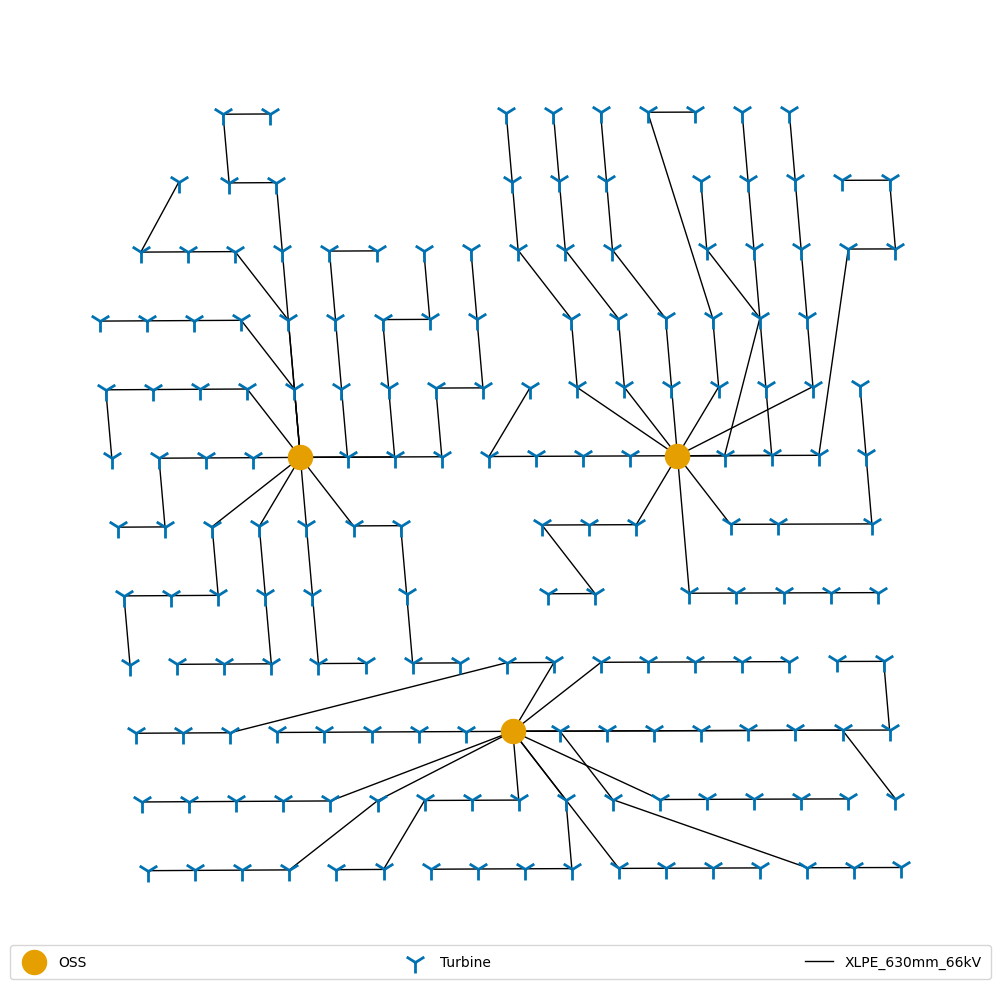

In [8]:
project.phases['CustomArraySystemDesign'].plot_array_system(show=True)

### Installation Actions

In [9]:
df = pd.DataFrame(project.actions)    # The project simulation logs are also available for all modules
df

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height,per_trip
0,0.5,Array Cable Installation Vessel,Mobilize,72.0000,2.948325e+05,ACTION,0.000000,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.5,Export Cable Installation Vessel,Mobilize,72.0000,2.948325e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.5,Export Cable Burial Vessel,Mobilize,72.0000,2.948325e+05,ACTION,0.000000,ExportCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Onshore Construction,Onshore Construction,0.0000,4.001844e+06,ACTION,0.000000,ExportCableInstallation,Landfall,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.5,Heavy Lift Vessel,Mobilize,72.0000,7.635915e+05,ACTION,0.000000,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10492,NaN,WTIV,Attach Blade,3.5000,4.754181e+04,ACTION,18130.561289,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
10493,NaN,WTIV,Release Blade,1.0000,1.358338e+04,ACTION,18131.561289,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10494,NaN,WTIV,Lift Blade,1.5000,2.037506e+04,ACTION,18133.061289,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
10495,NaN,WTIV,Attach Blade,3.5000,4.754181e+04,ACTION,18136.561289,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN


In [10]:
# These logs can be sorted by phase by using DataFrame operations

turbine_install = df.loc[df['phase']=="TurbineInstallation"]
turbine_install

,cost_multiplier,agent,action,duration,cost,level,time,phase,location,phase_name,max_waveheight,max_windspeed,transit_speed,site_depth,hub_height,per_trip
1266,1.0,WTIV,Mobilize,168.0000,2.282007e+06,ACTION,3120.043689,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1272,NaN,WTIV,Fasten Tower Section,4.0000,5.433350e+04,ACTION,3124.043689,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
1276,NaN,WTIV,Fasten Tower Section,4.0000,5.433350e+04,ACTION,3128.043689,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
1281,NaN,WTIV,Fasten Nacelle,4.0000,5.433350e+04,ACTION,3132.043689,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
1282,NaN,WTIV,Fasten Blade,1.5000,2.037506e+04,ACTION,3133.543689,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10492,NaN,WTIV,Attach Blade,3.5000,4.754181e+04,ACTION,18130.561289,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
10493,NaN,WTIV,Release Blade,1.0000,1.358338e+04,ACTION,18131.561289,TurbineInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10494,NaN,WTIV,Lift Blade,1.5000,2.037506e+04,ACTION,18133.061289,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN
10495,NaN,WTIV,Attach Blade,3.5000,4.754181e+04,ACTION,18136.561289,TurbineInstallation,NaN,TurbineInstallation,NaN,NaN,NaN,28.64,150.0,NaN


In [11]:
# Operations can also be grouped to see a total amount of time spend on each operation

turbine_install.groupby(["action"]).sum()['duration']

action
Attach Blade             1848.0000
Attach Nacelle           1056.0000
Attach Tower Section     2112.0000
Delay                     813.0000
Fasten Blade              792.0000
Fasten Nacelle            704.0000
Fasten Tower Section     1408.0000
Jackdown                   62.9376
Jackup                     62.9376
Lift Blade                792.0000
Lift Nacelle              264.0000
Lift Tower Section        396.0000
Mobilize                  168.0000
Position Onsite           352.0000
Reequip                   352.0000
Release Blade             528.0000
Release Nacelle           528.0000
Release Tower Section    1056.0000
Transit                  1890.0000
Name: duration, dtype: float64